<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv(r"C:\Users\lenovo-miguel\OneDrive\IBM_Data_Analytics_Coursera\survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [4]:
#let's get a specific dataset for this analysis, without missing values
df_dbwww= df[['DatabaseWantToWorkWith']].dropna()
print(df_dbwww.shape)
df_dbwww.head()

(42558, 1)


,DatabaseWantToWorkWith
1,PostgreSQL
2,Firebase Realtime Database
3,MongoDB;MySQL;PostgreSQL
4,PostgreSQL;SQLite
5,Cloud Firestore


In [5]:
#let's expand the dataframe by creating one row for each database when we have multiple options in DatabaseWantToWorkWith
df_dbwww['Database'] = df_dbwww['DatabaseWantToWorkWith'].str.split(';') # create a new column with a list of all database options
df_dbwww = df_dbwww.explode('Database') # replicate rows with more than one database in this new column
df_dbwww.head(10)

,DatabaseWantToWorkWith,Database
1,PostgreSQL,PostgreSQL
2,Firebase Realtime Database,Firebase Realtime Database
3,MongoDB;MySQL;PostgreSQL,MongoDB
3,MongoDB;MySQL;PostgreSQL,MySQL
3,MongoDB;MySQL;PostgreSQL,PostgreSQL
4,PostgreSQL;SQLite,PostgreSQL
4,PostgreSQL;SQLite,SQLite
5,Cloud Firestore,Cloud Firestore
7,Supabase,Supabase
9,MongoDB;MySQL;PostgreSQL;Redis,MongoDB


<Axes: title={'center': 'Pie Chart - percentage of top 5 most desired databases'}>

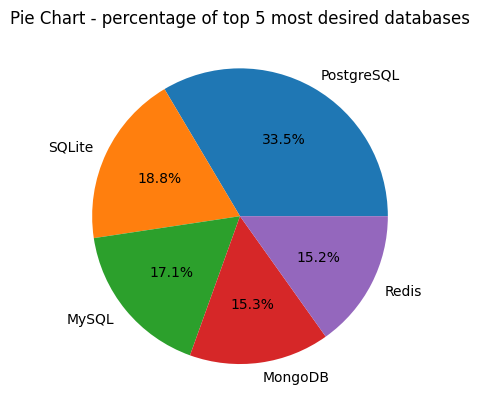

In [6]:
#let's get the top 5 most desired databases and plot the chart
db_top5 = df_dbwww['Database'].value_counts().head()
plt.figure()
plt.title('Pie Chart - percentage of top 5 most desired databases')
db_top5.plot(kind='pie', autopct='%1.1f%%', ylabel='')

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



In [7]:
#let's get a specific dataset for this analysis, without missing values
df_dt= df[['DevType']].dropna()
print(df_dt.shape)
df_dt.head()

(59445, 1)


,DevType
1,"Developer, full-stack"
2,Developer Experience
3,"Developer, full-stack"
4,"Developer, full-stack"
5,Student


<Axes: title={'center': "Pie Chart - percentage of top 5 respondents' developer roles"}>

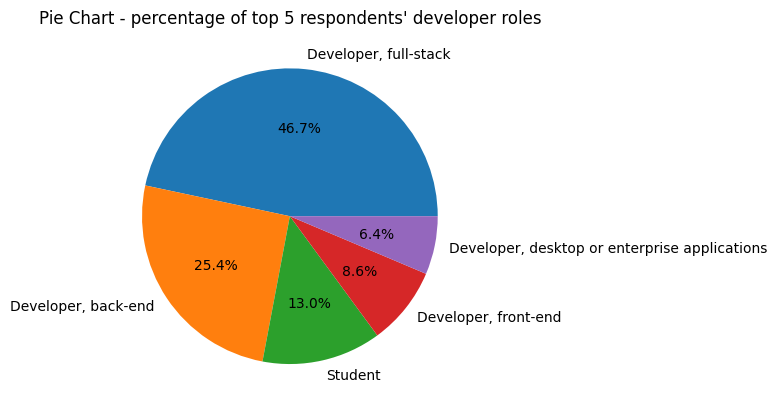

In [8]:
#let's get the top 5 developer roles and plot the chart
dt_top5 = df_dt['DevType'].value_counts().head()
plt.figure()
plt.title("Pie Chart - percentage of top 5 respondents' developer roles")
dt_top5.plot(kind='pie', autopct='%1.1f%%', ylabel='')

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [9]:
#let's get a specific dataset for this analysis, without missing values
df_ops= df[['OpSysProfessional use']].dropna()
print(df_ops.shape)
df_ops.head()

(52973, 1)


,OpSysProfessional use
1,MacOS
2,Windows
6,MacOS
7,MacOS
8,MacOS


In [10]:
#let's expand the dataframe by creating one row for each operating system when we have multiple options in OpSysProfessional use
df_ops['OpSys'] = df_ops['OpSysProfessional use'].str.split(';') # create a new column with a list of all operating system options
df_ops = df_ops.explode('OpSys') # replicate rows with more than one operating system in this new column
df_ops.head(10)

,OpSysProfessional use,OpSys
1,MacOS,MacOS
2,Windows,Windows
6,MacOS,MacOS
7,MacOS,MacOS
8,MacOS,MacOS
9,Windows,Windows
10,Windows,Windows
11,Windows;Windows Subsystem for Linux (WSL),Windows
11,Windows;Windows Subsystem for Linux (WSL),Windows Subsystem for Linux (WSL)
12,Windows Subsystem for Linux (WSL),Windows Subsystem for Linux (WSL)


<Axes: title={'center': 'Pie Chart - percentage of top 7 operating systems developers use professionaly'}>

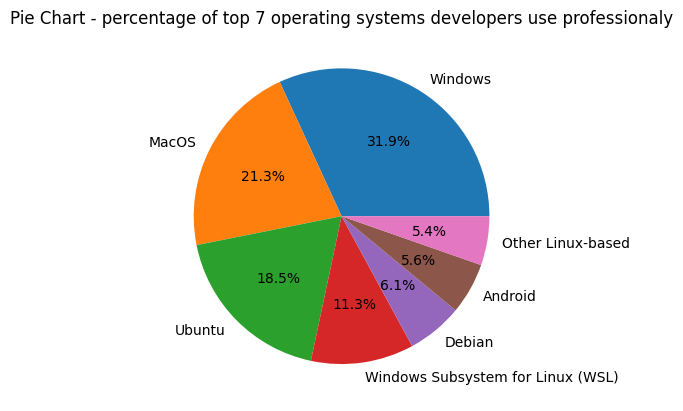

In [11]:
#let's get the top 7 operating systems and plot the chart
os_top7 = df_ops['OpSys'].value_counts().head(7)
plt.figure()
plt.title("Pie Chart - percentage of top 7 operating systems developers use professionaly")
os_top7.plot(kind='pie', autopct='%1.1f%%', ylabel='')

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



(59745, 1)


<Axes: title={'center': 'Pie Chart - percentage of top 5 languages developers have worked with'}>

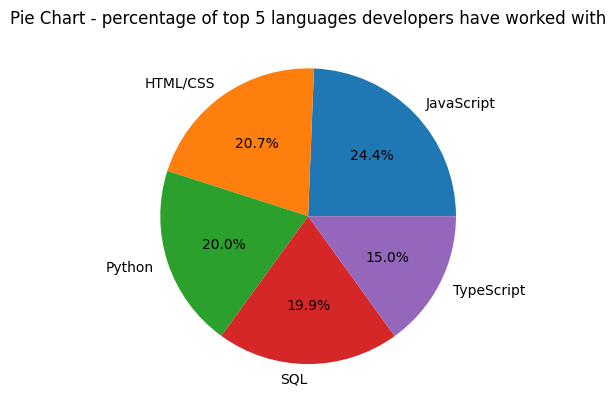

In [12]:
#let's get a specific dataset for this analysis, without missing values
df_lhww= df[['LanguageHaveWorkedWith']].dropna()
print(df_lhww.shape)

#let's expand the dataframe by creating one row for each language when we have multiple options in LanguageHaveWorkedWith
df_lhww['Language'] = df_lhww['LanguageHaveWorkedWith'].str.split(';') # create a new column with a list of all language options
df_lhww = df_lhww.explode('Language') # replicate rows with more than one language in this new column

#let's get the top 5 languages and plot the chart
lg_top7 = df_lhww['Language'].value_counts().head(5)
plt.figure()
plt.title("Pie Chart - percentage of top 5 languages developers have worked with")
lg_top7.plot(kind='pie', autopct='%1.1f%%', ylabel='')

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



(322233, 2)


<Axes: title={'center': 'Pie Chart - percentage of top 7 new collaboration tools developers have worked with'}>

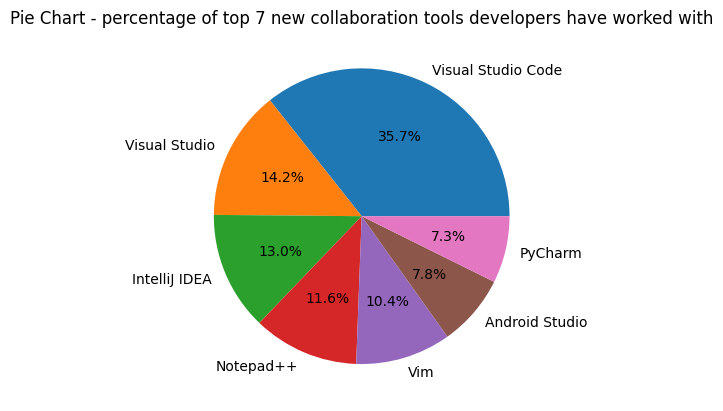

In [13]:
#let's get a specific dataset for this analysis, without missing values
df_nct = df[['NEWCollabToolsHaveWorkedWith']].dropna()
print(df_lhww.shape)

#let's expand the dataframe by creating one row for each new collaboration tool when we have multiple options in NEWCollabToolsHaveWorkedWith
df_nct['NewCT'] = df_nct['NEWCollabToolsHaveWorkedWith'].str.split(';') # create a new column with a list of all new collaboration tool options
df_nct = df_nct.explode('NewCT') # replicate rows with more than one collaboration tool in this new column

#let's get the top 7 collaboration tools and plot the chart
nct_top7= df_nct['NewCT'].value_counts().head(7)
plt.figure()
plt.title("Pie Chart - percentage of top 7 new collaboration tools developers have worked with")
nct_top7.plot(kind='pie', autopct='%1.1f%%', ylabel='')

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



(50872, 1)


<Axes: title={'center': 'Pie Chart - percentage of top 5 languages developers most admire'}>

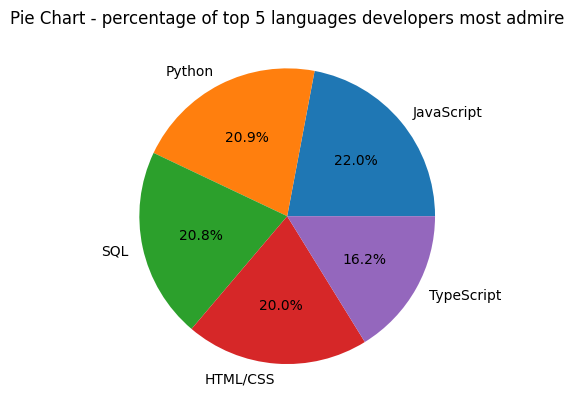

In [14]:
#let's get a specific dataset for this analysis, without missing values
df_la = df[['LanguageAdmired']].dropna()
print(df_la.shape)

#let's expand the dataframe by creating one row for each languag when we have multiple options in LanguageAdmired
df_la['Language'] = df_la['LanguageAdmired'].str.split(';') # create a new column with a list of all language options
df_la = df_la.explode('Language') # replicate rows with more than one language in this new column

#let's get the top 5 admired languages and plot the chart
la_top5= df_la['Language'].value_counts().head()
plt.figure()
plt.title("Pie Chart - percentage of top 5 languages developers most admire")
la_top5.plot(kind='pie', autopct='%1.1f%%', ylabel='')

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



(189203, 2)


<Axes: title={'center': 'Pie Chart - percentage of top 5 AI tools developers are currrently using'}>

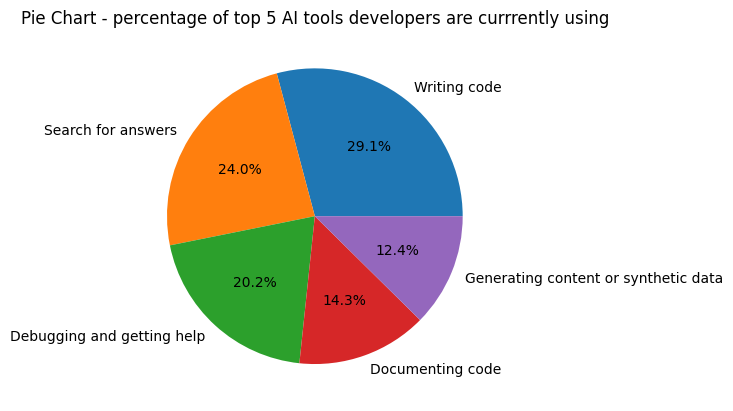

In [15]:
#let's get a specific dataset for this analysis, without missing values
df_ait = df[['AIToolCurrently Using']].dropna()
print(df_la.shape)

#let's expand the dataframe by creating one row for each AI tool when we have multiple options in AIToolCurrently Using
df_ait['AITool'] = df_ait['AIToolCurrently Using'].str.split(';') # create a new column with a list of all AI tool options
df_ait = df_ait.explode('AITool') # replicate rows with more than one AI tool in this new column

#let's get the top 5 AI tools and plot the chart
ait_top5= df_ait['AITool'].value_counts().head()
plt.figure()
plt.title("Pie Chart - percentage of top 5 AI tools developers are currrently using")
ait_top5.plot(kind='pie', autopct='%1.1f%%', ylabel='')

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



(189203, 2)


<Axes: title={'center': 'Pie Chart - percentage of top 5 web frameworks developers want to work with'}>

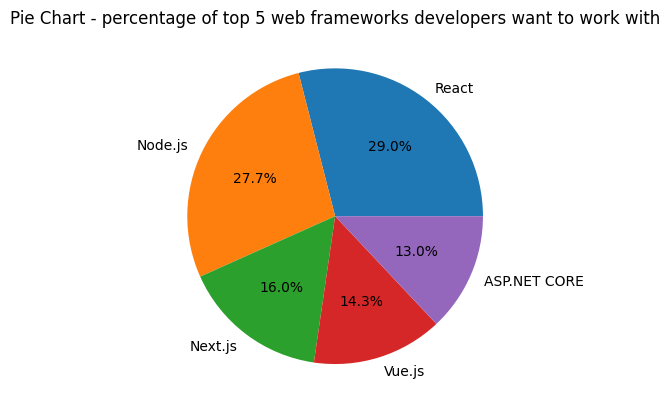

In [16]:
#let's get a specific dataset for this analysis, without missing values
df_wf = df[['WebframeWantToWorkWith']].dropna()
print(df_la.shape)

#let's expand the dataframe by creating one row for each web framework when we have multiple options in WebframeWantToWorkWith
df_wf['WebFram'] = df_wf['WebframeWantToWorkWith'].str.split(';') # create a new column with a list of all web framework options
df_wf = df_wf.explode('WebFram') # replicate rows with more than one web framework in this new column

#let's get the top 5 web frameworks and plot the chart
wf_top5= df_wf['WebFram'].value_counts().head()
plt.figure()
plt.title("Pie Chart - percentage of top 5 web frameworks developers want to work with")
wf_top5.plot(kind='pie', autopct='%1.1f%%', ylabel='')

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



(189203, 2)


<Axes: title={'center': 'Pie Chart - percentage of top 5 embedded frameworks developers want to work with'}>

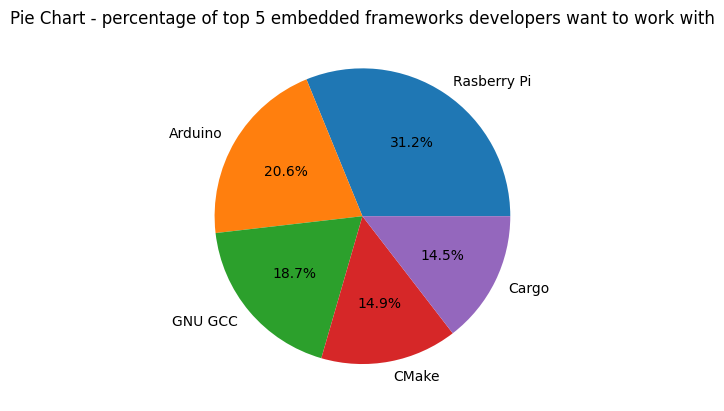

In [17]:
#let's get a specific dataset for this analysis, without missing values
df_ef = df[['EmbeddedWantToWorkWith']].dropna()
print(df_la.shape)

#let's expand the dataframe by creating one row for each embedded framework when we have multiple options in EmbeddedWantToWorkWith
df_ef['EmbFram'] = df_ef['EmbeddedWantToWorkWith'].str.split(';') # create a new column with a list of all embedded framework options
df_ef = df_ef.explode('EmbFram') # replicate rows with more than one embedded framework in this new column

#let's get the top 5 embedded frameworks and plot the chart
ef_top5= df_ef['EmbFram'].value_counts().head()
plt.figure()
plt.title("Pie Chart - percentage of top 5 embedded frameworks developers want to work with")
ef_top5.plot(kind='pie', autopct='%1.1f%%', ylabel='')

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
